# 配套实践 04-02：比较对比式与预测式视觉表征

本练习让两种小型模型观察同一目标的不同背景视图。对比模型把同一场景的两个视图拉近；简化预测模型根据被遮挡的上下文预测缓慢更新的目标表示。我们将检查背景变化下的相似度、位置读取误差和特征方差，而不是把二维散点图当作最终结论。依赖：PyTorch、NumPy、Matplotlib；Google Colab 的 CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/04-visual-representation-learning/" target="_blank">在新标签页返回课程正文</a>

In [1]:
import copy  # 复制在线编码器以创建目标编码器
import numpy as np  # 保存训练曲线并辅助绘图
import matplotlib.pyplot as plt  # 绘制视图、嵌入和评价结果
import torch  # 构造张量并训练视觉表示模型
from torch import nn  # 使用神经网络模块和损失函数
import torch.nn.functional as functional  # 使用归一化和交叉熵运算
torch.manual_seed(42)  # 固定数据、初始化和训练过程的随机性
np.random.seed(42)  # 固定 NumPy 侧的随机性
torch.set_num_threads(2)  # 限制 CPU 线程数量以适合在线环境

## 1. 为同一场景生成两个背景视图

每个场景由圆形目标的位置定义。视图 A 和视图 B 保持目标位置不变，却独立改变背景方向、强度和噪声，因此可以组成正样本。来自其他场景的视图不再保证目标位置相同，用作对比项。

In [2]:
image_size = 16  # 设置人工图像的边长
sample_count = 480  # 设置全部场景数量
position_generator = torch.Generator().manual_seed(42)  # 创建可重复的位置随机源
positions_px = torch.randint(3, 13, (sample_count, 2), generator=position_generator)  # 为每个场景采样目标像素位置
positions = positions_px.float() / (image_size - 1)  # 把像素位置归一化到零到一
grid_y, grid_x = torch.meshgrid(torch.arange(image_size), torch.arange(image_size), indexing="ij")  # 建立像素坐标网格
def render_views(pixel_positions, seed):  # 根据同一组目标位置生成一种背景视图
    generator = torch.Generator().manual_seed(seed)  # 为当前视图创建独立随机源
    rendered = torch.empty((len(pixel_positions), 1, image_size, image_size), dtype=torch.float32)  # 预留全部渲染图像
    for index, pixel_position in enumerate(pixel_positions):  # 逐个渲染目标和随机背景
        center_x = int(pixel_position[0].item())  # 读取当前目标水平位置
        center_y = int(pixel_position[1].item())  # 读取当前目标垂直位置
        use_horizontal = bool(torch.randint(0, 2, (1,), generator=generator).item())  # 随机选择背景纹理方向
        coordinate = grid_x if use_horizontal else grid_y  # 选择用于生成渐变的坐标轴
        strength = 0.08 + float(torch.rand(1, generator=generator).item() * 0.22)  # 随机设置背景变化强度
        offset = 0.03 + float(torch.rand(1, generator=generator).item() * 0.12)  # 随机设置背景基础亮度
        background = offset + strength * coordinate.float() / (image_size - 1)  # 生成与目标位置无关的平滑背景
        noise = torch.randn((image_size, image_size), generator=generator) * 0.02  # 模拟轻微传感器噪声
        image = (background + noise).clamp(0.0, 1.0)  # 把背景限制到有效灰度范围
        target_mask = (grid_x - center_x).square() + (grid_y - center_y).square() <= 4  # 找出圆形目标像素
        image[target_mask] = 0.95  # 在背景上绘制稳定亮度的目标
        rendered[index, 0] = image  # 保存当前视图图像
    return rendered  # 返回整组人工视图
views_a = render_views(positions_px, seed=101)  # 生成每个场景的第一种背景视图
views_b = render_views(positions_px, seed=202)  # 生成每个场景的第二种背景视图
train_a, test_a = views_a[:400], views_a[400:]  # 划分第一种视图的训练集与测试集
train_b, test_b = views_b[:400], views_b[400:]  # 划分第二种视图的训练集与测试集
train_positions, test_positions = positions[:400], positions[400:]  # 划分只用于评价的位置标签
assert train_a.shape == train_b.shape == (400, 1, 16, 16)  # 检查正样本两端接口完全一致

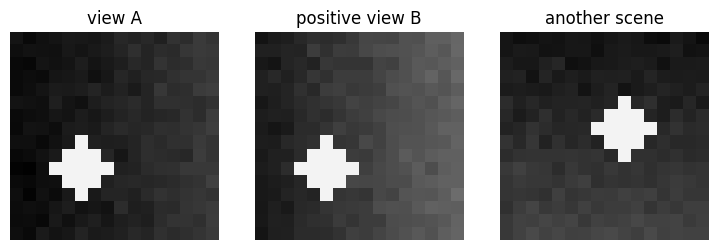

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))  # 创建正样本和对比项的展示画布
axes[0].imshow(train_a[0, 0], cmap="gray", vmin=0.0, vmax=1.0)  # 显示第一个场景的视图 A
axes[1].imshow(train_b[0, 0], cmap="gray", vmin=0.0, vmax=1.0)  # 显示同一场景的视图 B
axes[2].imshow(train_b[1, 0], cmap="gray", vmin=0.0, vmax=1.0)  # 显示另一个场景作为对比项
for title, axis in zip(["view A", "positive view B", "another scene"], axes):  # 为三幅图设置标题和显示格式
    axis.set_title(title)  # 标注当前视图在训练中的角色
    axis.axis("off")  # 隐藏不必要的像素刻度
plt.tight_layout()  # 调整三幅图之间的距离
plt.show()  # 显示样本关系

**怎样理解结果：** 前两幅图的背景不同，但圆形目标处于同一位置，因此本实验希望编码器对背景变化保持稳定。第三幅图来自另一个场景。这里把“同一目标位置”当作正样本语义只是教学设定；真实机器人任务必须重新判断颜色、视角、时间间隔等变化能否被安全忽略。

## 2. 定义对比模型与预测模型

对比模型直接比较 batch 内样本的相似度。预测模型的在线编码器读取被随机遮挡的上下文，预测器尝试得到目标视图的表示；目标编码器不接收当前损失梯度，只通过在线编码器参数的指数移动平均缓慢更新。

In [4]:
flat_size = image_size * image_size  # 计算展平图像的输入维度
feature_size = 12  # 设置便于观察的视觉表示维度
class SmallEncoder(nn.Module):  # 定义两种方法共用结构的小型编码器
    def __init__(self):  # 创建图像到十二维表示的映射
        super().__init__()  # 初始化 PyTorch 模块基类
        self.network = nn.Sequential(nn.Linear(flat_size, 96), nn.ReLU(), nn.Linear(96, feature_size))  # 压缩展平图像并保留任务因素
    def forward(self, flat_image):  # 定义编码器前向计算
        return self.network(flat_image)  # 返回未归一化的视觉表示
contrastive_encoder = SmallEncoder()  # 创建对比学习编码器
contrastive_optimizer = torch.optim.Adam(contrastive_encoder.parameters(), lr=2e-3)  # 创建对比模型优化器
online_encoder = SmallEncoder()  # 创建预测式学习的上下文编码器
target_encoder = copy.deepcopy(online_encoder)  # 用相同初始参数创建目标编码器
for parameter in target_encoder.parameters():  # 遍历目标编码器的全部参数
    parameter.requires_grad_(False)  # 禁止当前损失直接更新目标编码器
predictor = nn.Sequential(nn.Linear(feature_size, 32), nn.ReLU(), nn.Linear(32, feature_size))  # 创建上下文到目标表示的预测器
predictive_optimizer = torch.optim.Adam(list(online_encoder.parameters()) + list(predictor.parameters()), lr=2e-3)  # 联合优化在线编码器和预测器
def contrastive_loss(first_features, second_features, temperature=0.15):  # 定义跨视图的对称对比损失
    first_normalized = functional.normalize(first_features, dim=1)  # 把第一组表示归一化到单位长度
    second_normalized = functional.normalize(second_features, dim=1)  # 把第二组表示归一化到单位长度
    logits = first_normalized @ second_normalized.T / temperature  # 计算 batch 内全部跨视图相似度
    labels = torch.arange(len(first_features))  # 把相同索引规定为正样本配对
    return 0.5 * (functional.cross_entropy(logits, labels) + functional.cross_entropy(logits.T, labels))  # 同时约束两个检索方向
def update_target(momentum=0.98):  # 使用指数移动平均更新目标编码器
    with torch.no_grad():  # 确保更新不进入自动求导图
        for target_parameter, online_parameter in zip(target_encoder.parameters(), online_encoder.parameters()):  # 一一对应两个编码器参数
            target_parameter.mul_(momentum).add_(online_parameter, alpha=1.0 - momentum)  # 平滑跟随在线编码器而不瞬间复制

## 3. 训练两种表示

预测模型额外加入很小的维度方差约束。如果所有样本都输出同一个向量，预测误差可能看似不大，但表示已经坍缩；方差项要求不同样本至少保留一定变化。它不是任务语义保证，只是一种基本退化防护。

In [5]:
history = {"contrastive": [], "predictive": []}  # 保存两种方法各自的轮次损失
batch_size = 64  # 设置每次参数更新使用的场景数量
epoch_count = 45  # 设置轻量实验的训练轮数
for epoch in range(epoch_count):  # 多次遍历训练场景以学习表示
    order = torch.randperm(len(train_a))  # 每轮重新打乱场景顺序
    contrastive_losses = []  # 收集当前轮的对比损失
    predictive_losses = []  # 收集当前轮的预测损失
    for start in range(0, len(train_a), batch_size):  # 按小批量读取成对视图
        indices = order[start:start + batch_size]  # 取出当前 batch 的场景索引
        first_batch = train_a[indices].flatten(1)  # 展平当前 batch 的视图 A
        second_batch = train_b[indices].flatten(1)  # 展平同一批场景的视图 B
        first_features = contrastive_encoder(first_batch)  # 编码第一种背景视图
        second_features = contrastive_encoder(second_batch)  # 编码第二种背景视图
        current_contrastive_loss = contrastive_loss(first_features, second_features)  # 计算同索引靠近和其他索引分开的目标
        contrastive_optimizer.zero_grad()  # 清除对比模型上一步留下的梯度
        current_contrastive_loss.backward()  # 计算对比目标对编码器参数的梯度
        contrastive_optimizer.step()  # 根据梯度更新对比编码器
        context_mask = (torch.rand_like(first_batch) > 0.35).float()  # 随机隐藏部分上下文像素
        context_features = online_encoder(first_batch * context_mask)  # 从不完整上下文生成在线表示
        predicted_features = predictor(context_features)  # 根据上下文表示预测目标表示
        with torch.no_grad():  # 阻止当前损失通过目标分支反向传播
            target_features = target_encoder(second_batch)  # 从完整目标视图生成稳定学习目标
        alignment_loss = 2.0 - 2.0 * (functional.normalize(predicted_features, dim=1) * functional.normalize(target_features, dim=1)).sum(dim=1).mean()  # 计算归一化表示预测误差
        normalized_context = functional.normalize(context_features, dim=1)  # 去除仅靠向量长度制造差异的可能
        directional_std = torch.sqrt(normalized_context.var(dim=0) + 1e-4)  # 统计归一化表示在各方向上的变化
        variance_loss = functional.relu(0.18 - directional_std).mean()  # 惩罚所有样本指向近似相同方向的退化
        current_predictive_loss = alignment_loss + 2.0 * variance_loss  # 合并表示预测和方向防坍缩约束
        predictive_optimizer.zero_grad()  # 清除预测模型上一步留下的梯度
        current_predictive_loss.backward()  # 计算在线编码器和预测器梯度
        predictive_optimizer.step()  # 根据梯度更新在线分支参数
        update_target()  # 让目标编码器缓慢跟随更新后的在线编码器
        contrastive_losses.append(current_contrastive_loss.item())  # 保存当前 batch 的对比损失
        predictive_losses.append(current_predictive_loss.item())  # 保存当前 batch 的预测损失
    history["contrastive"].append(float(np.mean(contrastive_losses)))  # 保存当前轮平均对比损失
    history["predictive"].append(float(np.mean(predictive_losses)))  # 保存当前轮平均预测损失
    if epoch in {0, 9, 24, 44}:  # 只在关键轮次报告训练进度
        print(f"epoch={epoch + 1:02d} | contrastive={history['contrastive'][-1]:.4f} | predictive={history['predictive'][-1]:.4f}")  # 输出两种不同尺度的训练目标

epoch=01 | contrastive=1.8235 | predictive=1.5368
epoch=10 | contrastive=0.6595 | predictive=0.2162
epoch=25 | contrastive=0.5890 | predictive=0.0750
epoch=45 | contrastive=0.5714 | predictive=0.0598


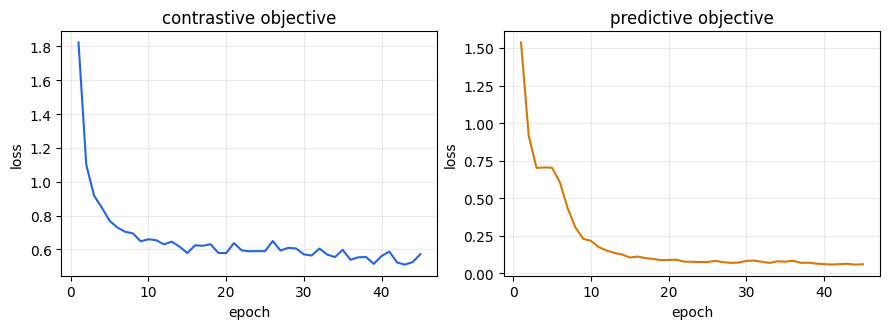

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))  # 为两种不可直接比较的损失创建独立坐标轴
axes[0].plot(np.arange(1, epoch_count + 1), history["contrastive"], color="#2563eb")  # 绘制对比损失下降趋势
axes[1].plot(np.arange(1, epoch_count + 1), history["predictive"], color="#d97706")  # 绘制预测损失下降趋势
axes[0].set_title("contrastive objective")  # 标注左图训练目标
axes[1].set_title("predictive objective")  # 标注右图训练目标
for axis in axes:  # 统一设置两幅训练曲线的坐标说明
    axis.set_xlabel("epoch")  # 标注横轴为训练轮数
    axis.set_ylabel("loss")  # 标注纵轴为当前方法的损失
    axis.grid(alpha=0.25)  # 添加较淡网格帮助读取趋势
plt.tight_layout()  # 调整两个子图的间距
plt.show()  # 显示两种方法各自的优化过程

**怎样理解结果：** 两条曲线下降只说明各自训练目标在当前数据上得到优化。对比损失包含 batch 内分类式比较，预测损失包含余弦预测和方差约束，因此绝对数值没有横向可比性。下一步必须直接检查表示在背景变化下是否稳定、是否仍保留目标位置。

## 4. 查看嵌入结构

十二维表示不适合直接绘制。下面只使用 PCA 将其投影到二维，并用目标的水平位置着色。二维图可以帮助发现趋势，但投影会丢失信息，不能代替后面的定量检查。

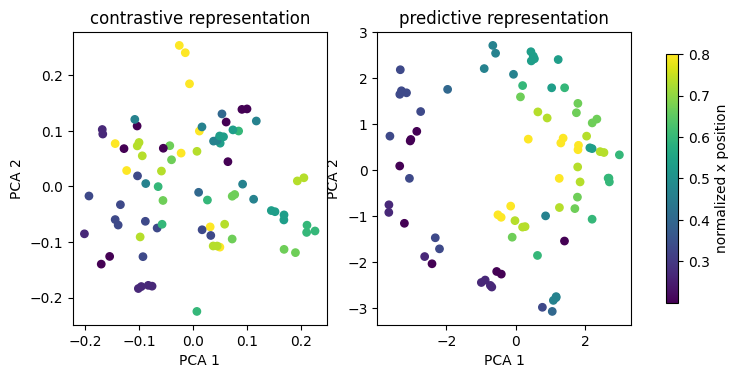

In [7]:
contrastive_encoder.eval()  # 把对比编码器切换到评估模式
online_encoder.eval()  # 把预测式在线编码器切换到评估模式
with torch.no_grad():  # 评价阶段关闭梯度记录
    contrastive_features_a = contrastive_encoder(test_a.flatten(1))  # 提取测试视图 A 的对比表示
    contrastive_features_b = contrastive_encoder(test_b.flatten(1))  # 提取测试视图 B 的对比表示
    predictive_features_a = online_encoder(test_a.flatten(1))  # 提取测试视图 A 的预测式表示
    predictive_features_b = online_encoder(test_b.flatten(1))  # 提取测试视图 B 的预测式表示
def project_to_two_dimensions(features):  # 用主变化方向把高维表示投影到二维
    centered = features - features.mean(dim=0, keepdim=True)  # 去除每个表示维度的均值
    _, _, right_vectors = torch.linalg.svd(centered, full_matrices=False)  # 求出表示数据的主方向
    return centered @ right_vectors[:2].T  # 返回前两个主方向上的二维坐标
contrastive_2d = project_to_two_dimensions(contrastive_features_a)  # 投影对比学习表示
predictive_2d = project_to_two_dimensions(predictive_features_a)  # 投影预测式学习表示
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=False, sharey=False)  # 创建两种嵌入的并排画布
first_scatter = axes[0].scatter(contrastive_2d[:, 0], contrastive_2d[:, 1], c=test_positions[:, 0], cmap="viridis", s=28)  # 按水平位置着色对比表示
axes[1].scatter(predictive_2d[:, 0], predictive_2d[:, 1], c=test_positions[:, 0], cmap="viridis", s=28)  # 按水平位置着色预测表示
axes[0].set_title("contrastive representation")  # 标注左侧嵌入来源
axes[1].set_title("predictive representation")  # 标注右侧嵌入来源
for axis in axes:  # 统一设置两个二维嵌入图
    axis.set_xlabel("PCA 1")  # 标注第一主方向
    axis.set_ylabel("PCA 2")  # 标注第二主方向
figure_colorbar = fig.colorbar(first_scatter, ax=axes, shrink=0.85)  # 添加两图共享的颜色说明
figure_colorbar.set_label("normalized x position")  # 说明颜色表示目标水平位置
plt.show()  # 显示两种表示的二维投影

**怎样理解结果：** 如果颜色在局部呈现较连续变化，说明目标水平位置影响了表示；颜色完全混杂也不等于高维表示一定没有位置信息，因为 PCA 只显示变化最大的两个方向。散点形状更不能证明模型已经识别出物体语义，所以还需要用原始十二维表示完成位置读出。

## 5. 检查背景稳定性、位置读取和坍缩迹象

第一幅柱形图比较同一场景两个背景视图的相似度与错配场景的相似度。第二幅图冻结编码器，用线性最小二乘头读取圆心位置。最后打印各维度平均标准差；常数表示的标准差会接近零，是最直接的坍缩症状。

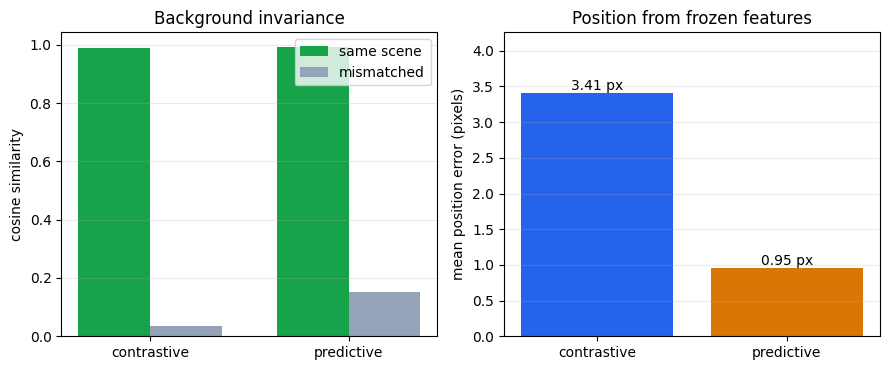

平均特征标准差 | contrastive=0.082, predictive=0.856, constant baseline=0.000


In [8]:
def mean_cosine(first_features, second_features):  # 计算一一对应样本的平均余弦相似度
    return float(functional.cosine_similarity(first_features, second_features, dim=1).mean().item())  # 返回便于绘图的标量
def append_bias(features):  # 为线性位置读出增加常数偏置列
    return torch.cat([features, torch.ones((len(features), 1))], dim=1)  # 拼接样本数量一致的常数列
def read_position(train_features, test_features):  # 拟合并评价冻结表示上的简单位置头
    weights = torch.linalg.lstsq(append_bias(train_features), train_positions).solution  # 求解训练集最小二乘映射
    predicted = append_bias(test_features) @ weights  # 使用同一映射预测测试位置
    errors = torch.linalg.vector_norm((predicted - test_positions) * (image_size - 1), dim=1)  # 把坐标误差转换成像素距离
    return float(errors.mean().item())  # 返回测试集平均像素误差
with torch.no_grad():  # 提取用于位置读出的训练表示
    contrastive_train_features = contrastive_encoder(train_a.flatten(1))  # 读取对比编码器训练表示
    predictive_train_features = online_encoder(train_a.flatten(1))  # 读取预测式编码器训练表示
same_similarities = [mean_cosine(contrastive_features_a, contrastive_features_b), mean_cosine(predictive_features_a, predictive_features_b)]  # 统计同场景跨背景相似度
mismatched_similarities = [mean_cosine(contrastive_features_a, contrastive_features_b.roll(1, 0)), mean_cosine(predictive_features_a, predictive_features_b.roll(1, 0))]  # 统计错配场景相似度
position_errors = [read_position(contrastive_train_features, contrastive_features_a), read_position(predictive_train_features, predictive_features_a)]  # 统计两种表示的位置读取误差
feature_stds = [float(contrastive_features_a.std(dim=0).mean().item()), float(predictive_features_a.std(dim=0).mean().item())]  # 统计表示维度的平均标准差
names = ["contrastive", "predictive"]  # 统一两种方法在图中的名称
x_locations = np.arange(len(names))  # 创建两组柱形的横轴位置
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))  # 创建相似度和位置误差两个简单面板
axes[0].bar(x_locations - 0.18, same_similarities, width=0.36, label="same scene", color="#16a34a")  # 绘制同场景跨背景相似度
axes[0].bar(x_locations + 0.18, mismatched_similarities, width=0.36, label="mismatched", color="#94a3b8")  # 绘制错配场景相似度
axes[0].set_xticks(x_locations, names)  # 标注两个表示学习方法
axes[0].set_ylabel("cosine similarity")  # 说明左图纵轴含义
axes[0].set_title("Background invariance")  # 标注左图检查的问题
axes[0].legend()  # 解释同场景与错配柱形
error_bars = axes[1].bar(names, position_errors, color=["#2563eb", "#d97706"])  # 绘制冻结表示的位置读取误差
axes[1].bar_label(error_bars, fmt="%.2f px")  # 在柱形上标出平均像素误差
axes[1].set_ylabel("mean position error (pixels)")  # 说明右图纵轴的实际单位
axes[1].set_title("Position from frozen features")  # 标注右图检查的问题
axes[1].set_ylim(0.0, max(position_errors) * 1.25)  # 为柱形数值保留顶部空间
for axis in axes:  # 为两个面板添加轻量参考网格
    axis.grid(axis="y", alpha=0.25)  # 添加不遮挡数据的横向网格
plt.tight_layout()  # 调整两个面板之间的间距
plt.show()  # 显示背景稳定性与位置读取结果
print(f"平均特征标准差 | contrastive={feature_stds[0]:.3f}, predictive={feature_stds[1]:.3f}, constant baseline=0.000")  # 报告坍缩诊断的直观数值
assert min(feature_stds) > 0.01  # 确认本次训练没有退化成近似常数表示

**怎样理解结果：** 同场景相似度高于错配相似度，说明表示能在一定程度上忽略本实验中的背景变化。位置误差则提出了另一个问题：对比模型即使很好地区分了样本，也未必把圆心组织成容易读取的坐标；预测模型在本次设定中可能得到更低误差，但这不是对所有数据都成立的方法排名。平均特征标准差明显高于常数基线，只能排除最直接的全常数坍缩，不能证明每个维度都有意义。

两种方法没有必要产生相同数值。对比学习利用 batch 中其他样本建立边界，预测式学习依赖目标编码器、上下文遮挡和方差防护。若正样本定义、遮挡区域或防坍缩机制改变，结果也会改变。

## 结论与练习

本实验把训练损失、二维可视化和任务读取分开评价。尝试把正样本改成不同目标位置的图像，或删掉预测目标中的方差约束，再观察相似度、位置误差和特征标准差。若损失仍下降而位置误差变差或标准差趋近零，这正说明训练成功不等于表征适合机器人任务。